In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# 1. Create a simulated non-linear dataset
np.random.seed(0)

# Independent variable (feature)
X = np.sort(5 * np.random.rand(80, 1), axis=0)

# Dependent variable (target), with non-linear relationship + noise
y = np.sin(X).ravel() + np.cos(X).ravel() * 2 + np.random.randn(80) * 0.5

print("Dataset created successfully.")


Dataset created successfully.


In [3]:
# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Data split: {len(X_train)} training samples, {len(X_test)} testing samples.")

# 3. Train the Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)
gb_model.fit(X_train, y_train)

print("Gradient Boosting model training complete.")


Data split: 56 training samples, 24 testing samples.
Gradient Boosting model training complete.


In [4]:
# 4. Make predictions on the testing data
y_pred = gb_model.predict(X_test)

print("Predictions made successfully.")
for i in range(min(5, len(X_test))):
    print(f"Actual: {y_test[i]:.2f}, Predicted: {y_pred[i]:.2f}")

# 5. Evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Predictions made successfully.
Actual: 0.37, Predicted: 0.92
Actual: 1.68, Predicted: 1.28
Actual: 2.30, Predicted: 1.09
Actual: 0.40, Predicted: -0.01
Actual: 1.36, Predicted: 2.14

Model Evaluation:
Mean Squared Error (MSE): 0.39
R² Score: 0.87


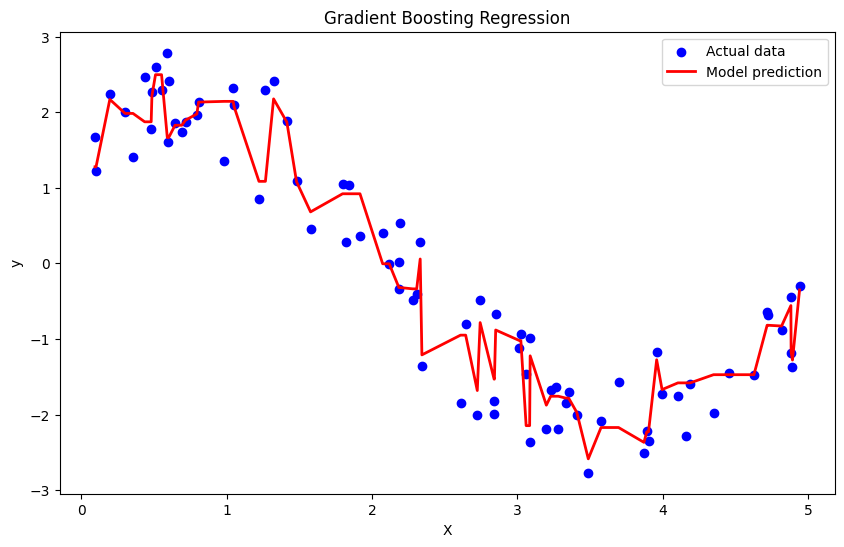

In [5]:
# 6. Visualize the results
X_sorted = np.sort(X, axis=0)
y_pred_sorted = gb_model.predict(X_sorted)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color="blue", label="Actual data")
plt.plot(X_sorted, y_pred_sorted, color="red", linewidth=2, label="Model prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Gradient Boosting Regression")
plt.legend()
plt.show()
